MCP (Model Context Protocol) 是由 Anthropic 推出的开放标准，用于便捷的将AI应用连接外部系统。

在没有MCP的时候，必须手动定义工具，用工具实现文件操作、web搜索、查询航班、查询天气等功能，从而让AI连接外部系统。

这就存在两个问题：
- 不同Agent可能有同样的tool需求，每次都重复定义，复用性差
- 全世界有各种不同的服务，不同服务接口不同，定义Tool非常麻烦

MCP就像是AI世界的USB接口协议：
- 所有外部服务提供者都可以遵循MCP协议提供Tool，分享自己的Tool服务
- AI应用基于MCP协议对接任意遵循MCP的外部服务，无需自己定义Tool

这样一来就解决了重复定义工具的复用性问题、以及对接全世界各种公共服务的问题。

## 1. MCP核心概念
在MCP中有三个核心概念：
| 概念 | 说明 |
| --- | --- |
| MCP Server | 提供MCP服务的应用，可以是远程服务，也可以是本地服务 |
| MCP Client | 连接到MCP服务器，读取MCP信息（特别是Tool信息），供Host使用 |
| MCP Host | 协调和管理多个MCP Client的AI应用，比如LangChain的Agent |

例如，一个AI应用，也就是MCP Host，它需要三个功能：
- 文件操作
- 数据库操作
- Sentry远程服务
此时，它可以定义3个不通的MCP Client，分别对接3个MCP Server，包含一个操作本地文件的MCP、一个访问数据库的MCP、一个访问Sentry服务的MCP
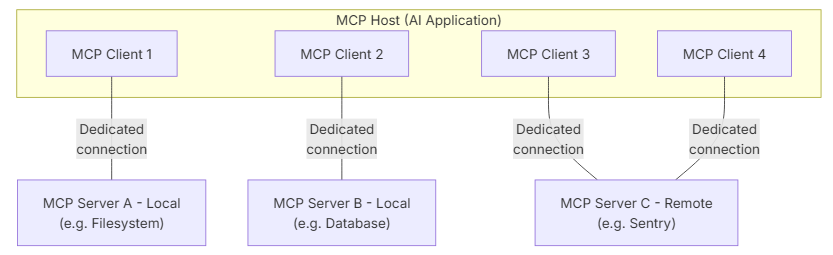
MCP Client 与 MCP Server之间有两种通信方式：
- stdio
- SSE（基于http）

stdio就是标准输入输出，MCP Client运行时，分两种情况：
- 外部服务：Client会把这个MCP服务的脚本下载到本地，然后作为一个子进程运行。
- 本地服务：Client会把本地脚本直接加载，作为一个子进程运行
也就是说，stdio模式中，MCP Client 和 MCP Server之间的通信就是进程通信，没有网络延迟。

SSE就是Server Event Stream，我们之前有介绍过，通常是基于http协议的一种持续数据交互模式。也就是说MCP client通过发送http请求与MCP server交互。存在网络延迟。

详细的MCP说明可以参考Anthropic公司的MCP官方文档：
https://modelcontextprotocol.io/docs/getting-started/intro

LangChain本身实现了对MCP的支持，本节我们就来学习如何在LangChain中使用MCP

## 2. 连接外部MCP服务

很多提供云服务的公司都提供了MCP服务，例如：
- Amap Maps : 高德地图提供的MCP
- Filesystem : 可以操作文件系统的MCP
- Time : 查询当前时间的MCP服务
- Kiwi : 查询航班、预定航班的MCP服务
- ...

大家可以在https://mcp.so/zh/搜索各种MCP服务：

找好自己想要使用的MCP服务后，就可以用LangChain来对接了。

首先，我们需要安装LangChain的MCP依赖库:
```bash
uv add langchain-mcp-adapters
```

接下来，就可以用LangChain对接MCP服务，获取其提供的工具，创建Agent了。

接下来，我们以两个MCP服务为例来介绍LangChain对接MCP服务的方式：
- Time MCP ：基于stdio通信
- Kiwi MCP : 基于http通信

2.1 Time MCP服务
Time是一个提供时间和时区转换功能的MCP服务。此服务使LLM能够获取当前时间信息，并使用 IANA 时区名称执行时区转换，同时具备自动检测系统时区的功能。
查看Time MCP的介绍页面，可以看到其介绍，以及集成方式：
https://mcp.so/zh/server/time/modelcontextprotocol
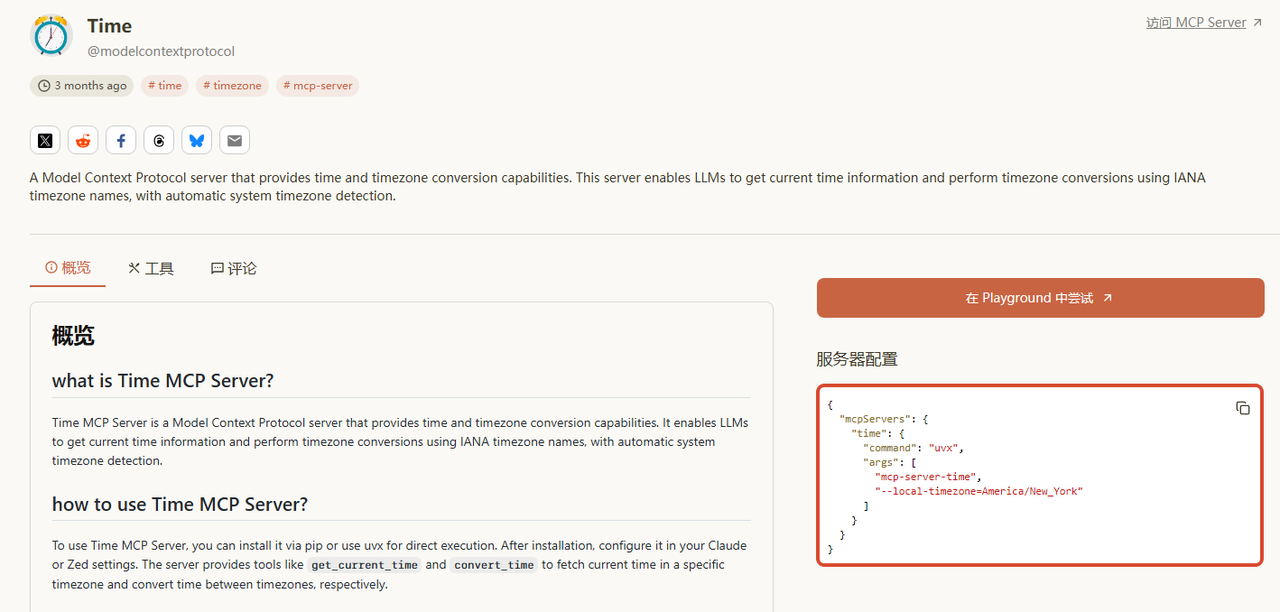

需要注意的是，Time MCP是基于stdio的通信方式，也就是把这个MCP服务的脚本下载到本地，然后作为一个子进程运行。
其中，MCP脚本下载的方式取决于配置中的command，常见的有两种：
- npx : 基于node.js的包管理工具
- uvx : 基于uv(python的uv工具)的包管理工具
因此，你的本地环境必须支持npx、uvx命令

另外，在LangChain中除了基本的服务器配置，还必须设置一个transport参数，指定MCP服务的通信方式，有两个可选值：
- stdio
- http或者streamable_http

示例代码：

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# 连接Time MCP服务器
client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "uvx",
            "args": [
                "mcp-server-time",
                "--local-timezone=Asia/Shanghai"
            ]
        }
    }
)

# 注意MultiServerMCPClient是异步的，结果都是协程对象，需要await
tools = await client.get_tools()

In [ ]:
for tool in tools:
    print(tool.name)
    print(tool.description)
    print("-----------------------")

接下来，就可以像正常使用Tool那样创建Agent即可：

In [ ]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

agent = create_agent("deepseek-chat", tools)

response = await agent.ainvoke({
    "messages": [HumanMessage("现在几点了？")]
})

for message in response["messages"]:
    message.pretty_print()

### 2.2 Kiwi MCP服务
Kiwi Travel MCP 将 Kiwi.com 的航班搜索功能直接引入到 AI 对话中。支持单程/往返、灵活日期、多名乘客以及所有舱位等级。
注意：
- Kiwi服务是基于http的通信方式，也就是说MCP client通过发送http请求与MCP server交互，在国内访问存在较大网络延迟。
- 通常这类外部的MCP服务都是需要收费的，需要申请API key才能使用，而Kiwi是仅有的免费航班搜索服务
查看Kiwi介绍页，可以找到它的使用方式：https://mcp.so/zh/server/kiwi-travel-mcp/Vytautas%20Dargis
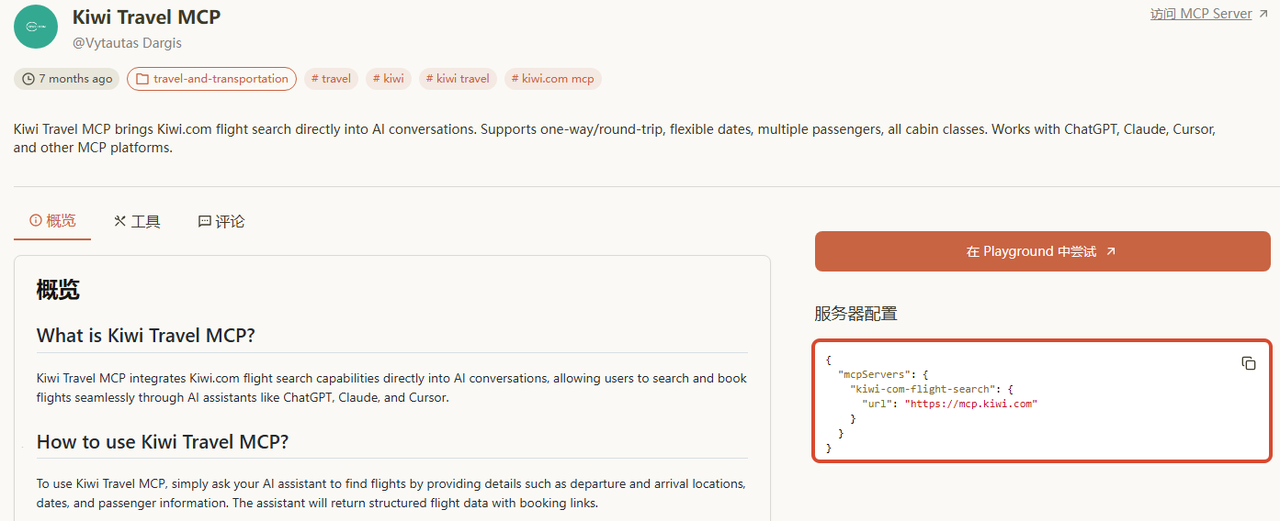
示例代码：

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

# 连接Kiwi MCP服务器
client = MultiServerMCPClient(
    {
        "kiwi-com-flight-search": {
            "transport": "http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

# 注意MultiServerMCPClient是异步的，结果都是协程对象，需要await
tools = await client.get_tools()


agent = create_agent(
    model="deepseek-chat",
    tools=tools,
    system_prompt="You are a travel agent. Help user find best flights. No follow up questions. If the user uses Chinese, use zh-cn as the locale value."
)

response = await agent.ainvoke({
    "messages": [HumanMessage("查一下2026年5月15日晚上从北京飞杭州的航班。")]
})

for message in response["messages"]:
    message.pretty_print()

由于Kiwi中有地域参数（locale），但Tool描述中没说清楚，中文有两种：zh-cn,zh-tw，需要在系统提示词中说明，否则AI默认会传入zh，导致报错。

## 3. 自定义MCP服务
在公司内部，不同团队之间也可以把自己团队的服务开发成MCP Server，供其它团队使用。

接下来，我们就学习如何自定义MCP服务。

### 3.1 创建简单的MCP服务器
自定义MCP最简单的方式就是使用FastMCP了。
首先，需要安装依赖：
```
uv add fastmcp
```

接着，只需要定义几个方法，然后利用FastMCP提供的装饰器即可：
- @mcp.tool : 作为MCP中的工具
- @mcp.resources : 返回MCP需要的resources，类似拓展知识库
- @mcp.prompt : 返回MCP预定义的Prompt，预设的提示词
说明：MCP server端不仅可以提供tool，还可以提供resource、prompt，但通常不太常用，一般只需要提供tool即可。
通常我们只需要定义带有tool的MCP Server就可以了。

例如，我们定义一个数学运算的MCP服务，这个需要写到单独的py文件中，比如math_mcp_server.py：

In [ ]:
from fastmcp import FastMCP

# 初始化mcp
mcp = FastMCP("Math")


# mcp tools
@mcp.tool()
def add(a: float, b: float) -> float:
    """Add two numbers"""
    return a + b


@mcp.tool()
def multiply(a: float, b: float) -> float:
    """Multiply two numbers"""
    return a * b


@mcp.tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5


# 启动mcp服务，通信方式设置为stdio
if __name__ == "__main__":
    mcp.run(transport="stdio")

一个自定义MCP server就准备好了。
注意，由于我们是采用stdio方式，因此这个文件写好放在那里，不需要启动，将来MCP Client会自己启动并加载为子进程。

### 3.2 连接接自定义MCP服务
由于我们自定义的MCP是本地py文件，所以启动的Command直接就是python，而不是npx或uvx

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

# 连接自定义MCP服务
client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "python",
            "args": ["math_mcp_server.py"]
        }
    }
)
# 获取工具
tools = await client.get_tools()

# 创建agent
agent = create_agent(
    model="deepseek-chat",
    tools=tools,
    system_prompt="You are a helpful agent. You must use tools to answer math question."
)

# 调用测试
response = await agent.ainvoke({
    "messages": [HumanMessage("467和529的平方根之和是多少?")]
})

for message in response["messages"]:
    message.pretty_print()

## 4. 总结

1. MCP是什么
  - 开放协议，标准化LLM应用获取工具的方式
  - 客户端-服务器架构
2. 连接方式
  - STDIO: 本地MCP服务器
  - HTTP: 远程MCP服务器
3. 使用流程
  - 配置MultiServerMCPClient
  - 调用get_tools()获取工具
  - 创建Agent并调用
4. 自定义MCP Server
  - 导入FastMCP
  - 使用@mcp.tool装饰函数，定义工具（必备）
  - 使用@mcp.resource装饰函数，返回resources（可选）
  - 使用@mcp.prompt装饰函数，返回Prompt（可选）
  - 使用mcp.run()启动MCP服务